Files processed: 1281
list_freqs: 1281
list_triplets: 1281
Temperature points in plot range (Open_air): 4376
Temperature points in plot range (1762nm_box): 4376
Temperature binning (minutes): 5


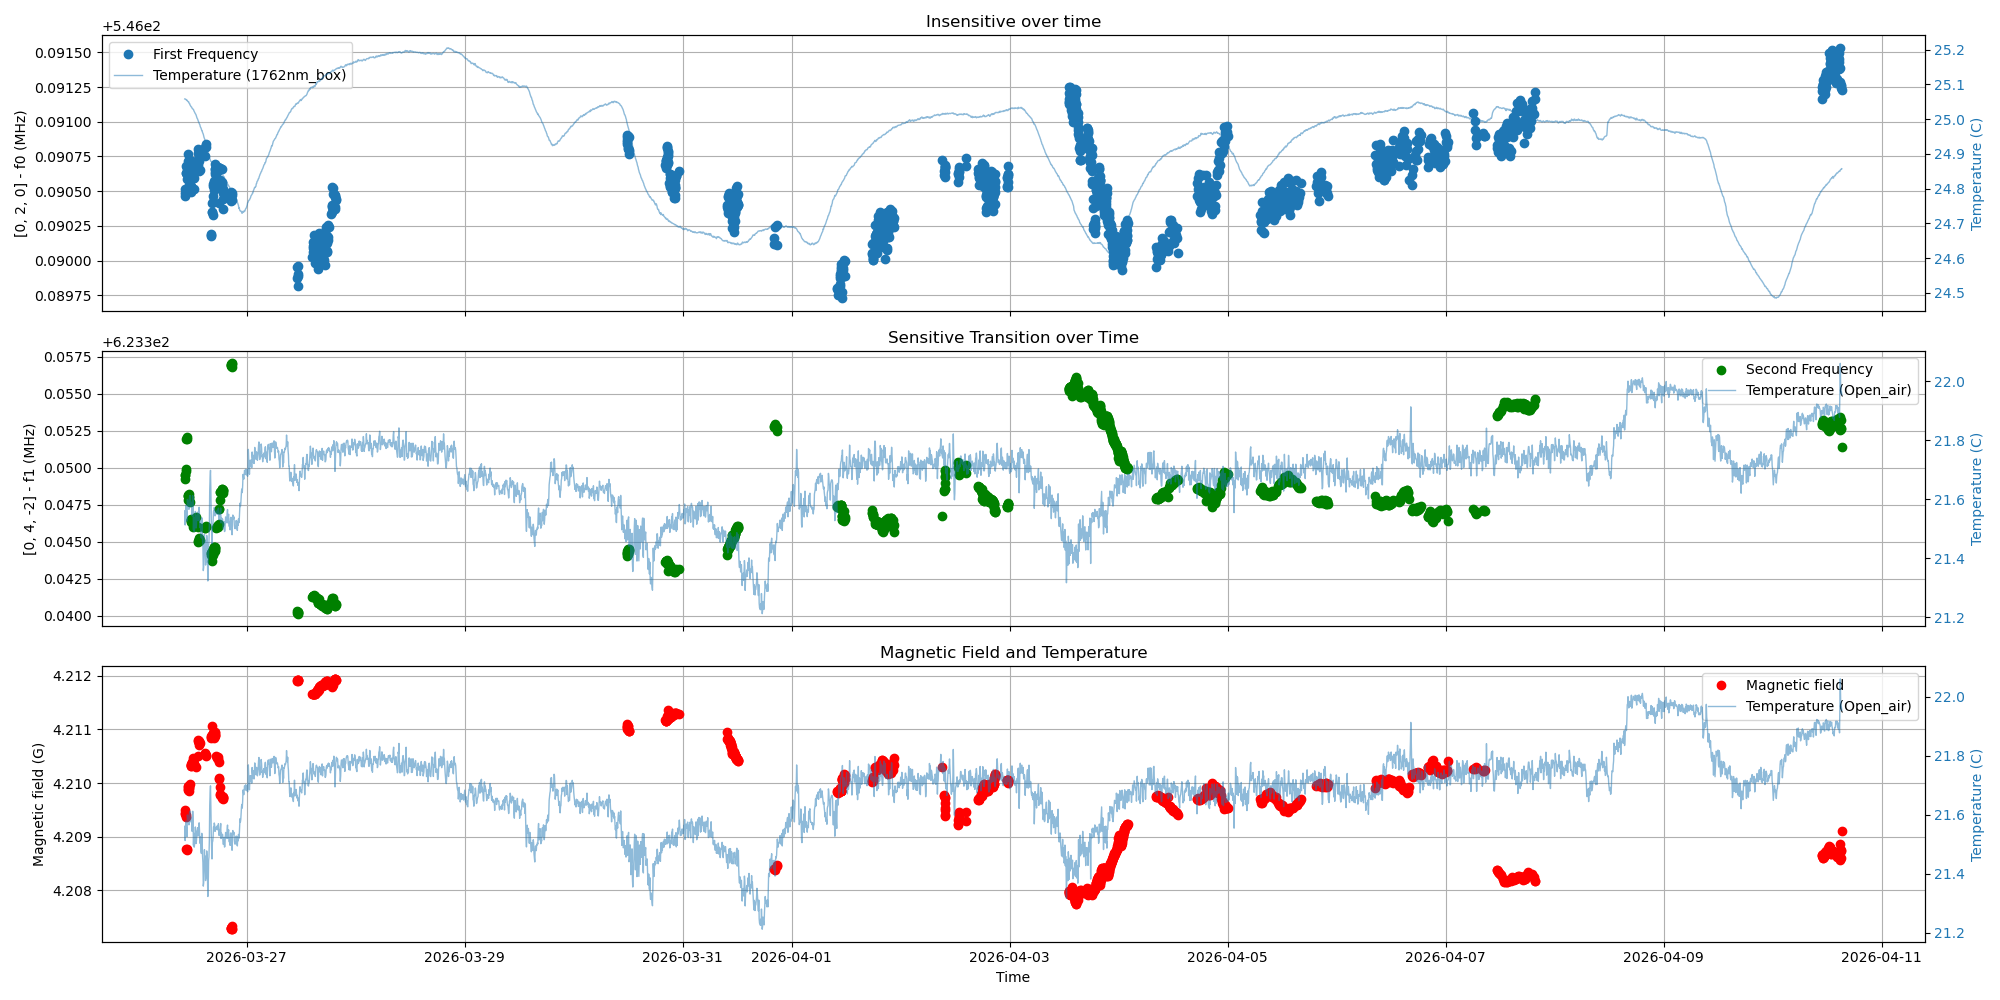

In [9]:
import os
import re
import json
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np

# Define the folders containing the files
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

# Temperature log folders
temp_base_folder_default = r"Z:\Lab_HPT_logs\Open_air"
temp_base_folder_top_insensitive = r"Z:\Lab_HPT_logs\1762nm_box"
TEMP_BIN_MINUTES = 5  # Set to None, 1, or 5

# Define date-time filter (Modify as needed)
# start_date = datetime(2026, 2, 17, 0, 0, 0)  # Change to desired start datetime
start_date = datetime(2026, 3, 25, 0, 0, 0)
end_date = datetime(2026, 12, 15, 0, 0, 59)  # Change to desired end datetime (Optional)

temp_line_pattern = re.compile(
    r"^(?P<time>\d{2}:\d{2}:\d{2})\s*-\s*.*?\bAvg Temp:\s*(?P<temp>[-+]?\d*\.?\d+)"
)
temperature_cache = {}


def load_temperature_for_day(day_dt, base_folder):
    """Load one day of temperature logs from YYYY_MM/YYYY_MM_DD[.txt]."""
    cache_key = (base_folder, day_dt.date())
    if cache_key in temperature_cache:
        return temperature_cache[cache_key]

    month_dir = os.path.join(base_folder, day_dt.strftime("%Y_%m"))
    day_stem = day_dt.strftime("%Y_%m_%d")
    day_candidates = [
        os.path.join(month_dir, day_stem),
        os.path.join(month_dir, f"{day_stem}.txt"),
    ]

    day_file = next((path for path in day_candidates if os.path.isfile(path)), None)
    if day_file is None:
        temperature_cache[cache_key] = ([], [])
        return temperature_cache[cache_key]

    day_times = []
    day_temps = []

    with open(day_file, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            match = temp_line_pattern.search(line.strip())
            if not match:
                continue

            try:
                sample_time = datetime.strptime(match.group("time"), "%H:%M:%S").time()
                sample_dt = datetime.combine(day_dt.date(), sample_time)
                sample_temp = float(match.group("temp"))
            except ValueError:
                continue

            day_times.append(sample_dt)
            day_temps.append(sample_temp)

    if day_times:
        paired = sorted(zip(day_times, day_temps), key=lambda x: x[0])
        day_times, day_temps = map(list, zip(*paired))
    else:
        day_times, day_temps = [], []

    temperature_cache[cache_key] = (day_times, day_temps)
    return temperature_cache[cache_key]


def load_temperature_series(start_dt, end_dt, base_folder):
    """Load all temperature samples in the [start_dt, end_dt] range."""
    if start_dt is None or end_dt is None or end_dt < start_dt:
        return np.array([], dtype=object), np.array([], dtype=float)

    all_times = []
    all_temps = []

    current_day = start_dt.date()
    last_day = end_dt.date()

    while current_day <= last_day:
        day_dt = datetime.combine(current_day, datetime.min.time())
        day_times, day_temps = load_temperature_for_day(day_dt, base_folder)

        if day_times:
            for t, temp in zip(day_times, day_temps):
                if start_dt <= t <= end_dt:
                    all_times.append(t)
                    all_temps.append(temp)

        current_day += timedelta(days=1)

    return np.array(all_times, dtype=object), np.array(all_temps, dtype=float)


def bin_temperature_series(temp_times, temp_values, bin_minutes=None):
    """Bin temperature points into fixed-minute bins using mean temperature."""
    if bin_minutes is None:
        return temp_times, temp_values

    if bin_minutes not in (1, 5):
        raise ValueError("TEMP_BIN_MINUTES must be None, 1, or 5")

    if temp_values.size == 0:
        return temp_times, temp_values

    bins = {}
    for t, temp in zip(temp_times, temp_values):
        floored_minute = (t.minute // bin_minutes) * bin_minutes
        bin_dt = t.replace(minute=floored_minute, second=0, microsecond=0)
        bins.setdefault(bin_dt, []).append(float(temp))

    binned_times = sorted(bins.keys())
    binned_values = [np.mean(bins[bt]) for bt in binned_times]
    return np.array(binned_times, dtype=object), np.array(binned_values, dtype=float)


# Lists to store the extracted data
list_freqs = []
list_triplets = []
file_times = []

# Iterate through all files in both folders
for folder_path in folder_paths:
    if not os.path.isdir(folder_path):
        print(f"Skipping missing folder: {folder_path}")
        continue

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # Skip if not a file
        if not os.path.isfile(file_path):
            continue

        # Get file modification time
        mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))

        # Check if the file is within the date-time range
        if start_date <= mod_time <= end_date:
            file_times.append(mod_time)

            # Read the file and process its contents
            with open(file_path, "r") as file:
                try:
                    lines = file.readlines()
                    bottom_list = json.loads(lines[1].strip())
                    list_triplets.append(bottom_list)
                    top_list = json.loads(lines[0].strip())
                    list_freqs.append(top_list)
                except (IndexError, json.JSONDecodeError) as e:
                    print(f"Error processing file {file_path}: {e}")


# Display the results
print("Files processed:", len(file_times))
print("list_freqs:", len(list_freqs))
print("list_triplets:", len(list_triplets))

# Sort data by modification time
sorted_data = sorted(zip(file_times, list_freqs), key=lambda x: x[0])
sorted_times, sorted_freqs = zip(*sorted_data) if sorted_data else ([], [])

# Extract first and second frequency values
first_freq_values = [freq[0] for freq in sorted_freqs if len(freq) > 1]
second_freq_values = [freq[1] for freq in sorted_freqs if len(freq) > 1]

num_points = min(len(sorted_times), len(first_freq_values), len(second_freq_values))
sorted_times = list(sorted_times[:num_points]) if num_points else []
first_freq_values = np.array(first_freq_values[:num_points], dtype=float)
second_freq_values = np.array(second_freq_values[:num_points], dtype=float)

# Compute the magnetic field from frequency differences
if num_points > 0:
    freq_differences = (second_freq_values - first_freq_values) / (-3.498)
    freq_differences = 4.2095 + freq_differences - freq_differences[0]

    # Compute slope dB/dt
    time_seconds = np.array([(t - sorted_times[0]).total_seconds() for t in sorted_times], dtype=float)
    dB_dt = np.gradient(freq_differences, time_seconds) if num_points > 1 else np.array([0.0])
else:
    freq_differences = np.array([])
    time_seconds = np.array([])
    dB_dt = np.array([])

# Define what "big slope" means (tune this!)
slope_threshold = np.std(dB_dt) * 0.8 if dB_dt.size else 0.0
large_slope_mask = np.abs(dB_dt) > slope_threshold if dB_dt.size else np.array([], dtype=bool)
bad_time_mask = large_slope_mask
good_time_mask = ~bad_time_mask

# Find contiguous regions where slope is large
regions = []
start_idx = None

for i, val in enumerate(large_slope_mask):
    if val and start_idx is None:
        start_idx = i
    elif not val and start_idx is not None:
        regions.append((start_idx, i - 1))
        start_idx = None

if start_idx is not None:
    regions.append((start_idx, len(large_slope_mask) - 1))

# Load temperature points within plotted x-range
if sorted_times:
    temp_times_default, temp_values_default = load_temperature_series(
        sorted_times[0], sorted_times[-1], temp_base_folder_default
    )
    temp_times_top, temp_values_top = load_temperature_series(
        sorted_times[0], sorted_times[-1], temp_base_folder_top_insensitive
    )
else:
    temp_times_default, temp_values_default = np.array([], dtype=object), np.array([], dtype=float)
    temp_times_top, temp_values_top = np.array([], dtype=object), np.array([], dtype=float)

temp_times_default, temp_values_default = bin_temperature_series(
    temp_times_default, temp_values_default, TEMP_BIN_MINUTES
)
temp_times_top, temp_values_top = bin_temperature_series(
    temp_times_top, temp_values_top, TEMP_BIN_MINUTES
)

print("Temperature points in plot range (Open_air):", len(temp_times_default))
print("Temperature points in plot range (1762nm_box):", len(temp_times_top))
print("Temperature binning (minutes):", TEMP_BIN_MINUTES)

# Create a single figure with subplots
fig, ax = plt.subplots(3, 1, figsize=(20, 10), sharex=True)

# # --- Linear fit for top subplot: first_freq_values vs time ---
# if len(sorted_times) >= 2:
#     t0 = sorted_times[0]
#     t_sec = np.array([(t - t0).total_seconds() for t in sorted_times], dtype=float)

#     # Fit: f_MHz = m*t + b
#     m_mhz_per_s, b_mhz = np.polyfit(t_sec, first_freq_values, 1)

#     # Convert slope to Hz/s (since first_freq_values are in MHz)
#     m_hz_per_s = m_mhz_per_s * 1e6
#     print(m_hz_per_s)
#     fit_line = m_mhz_per_s * t_sec + b_mhz
#     slope_text = f"Slope = {m_hz_per_s:.3g} Hz/s"
# else:
#     fit_line = None
#     slope_text = "Slope = N/A"

# # --- Plot first frequency vs. time (with fit) ---
# ax[0].plot(sorted_times, first_freq_values, "o", label="First Frequency")

# if fit_line is not None:
#     ax[0].plot(sorted_times, fit_line, "-", label=slope_text)

ax[0].set_ylabel("[0, 2, 0] - f0 (MHz)")
ax[0].set_title("Insensitive over time")
ax[0].grid(True)

# Plot first frequency vs. time
ax[0].plot(sorted_times, first_freq_values, "o", label="First Frequency")
ax[0].set_ylabel("[0, 2, 0] - f0 (MHz)")
ax[0].set_title("Insensitive over time")
ax[0].grid(True)

# Plot second frequency vs. time
ax[1].plot(sorted_times, second_freq_values, "go", label="Second Frequency")
ax[1].set_ylabel("[0, 4, -2] - f1 (MHz)")
ax[1].set_title("Sensitive Transition over Time")
ax[1].grid(True)

# Plot magnetic field vs. time
ax[2].plot(sorted_times, freq_differences, "o", color="r", label="Magnetic field")
ax[2].set_xlabel("Time")
ax[2].set_ylabel("Magnetic field (G)")
ax[2].set_title("Magnetic Field and Temperature")
ax[2].grid(True)

# Plot temperature on right y-axis for all 3 subplots
temp_color = "tab:blue"
ax_temp = []
for i, axis in enumerate(ax):
    temp_axis = axis.twinx()

    if i == 0:
        t_times = temp_times_top
        t_vals = temp_values_top
        t_label = "Temperature (1762nm_box)"
    else:
        t_times = temp_times_default
        t_vals = temp_values_default
        t_label = "Temperature (Open_air)"

    if t_vals.size:
        temp_axis.plot(
            t_times,
            t_vals,
            "-",
            color=temp_color,
            linewidth=1,
            alpha=0.5,
            label=t_label,
        )

    temp_axis.set_ylabel("Temperature (C)", color=temp_color)
    temp_axis.tick_params(axis="y", labelcolor=temp_color)
    ax_temp.append(temp_axis)

# Combine legends from both y-axes on each subplot
for i, axis in enumerate(ax):
    lines_left, labels_left = axis.get_legend_handles_labels()
    lines_right, labels_right = ax_temp[i].get_legend_handles_labels()
    if lines_left or lines_right:
        axis.legend(lines_left + lines_right, labels_left + labels_right, loc="best")

# Shade regions on all subplots
# for start, end in regions:
#     t_start = sorted_times[start]
#     t_end = sorted_times[end]
#     for axis in ax:
#         axis.axvspan(t_start, t_end, alpha=0.3, color='gray')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.savefig("freq_deviation_over_time.png")
plt.show()



In [7]:
%matplotlib widget

Points loaded: 1735


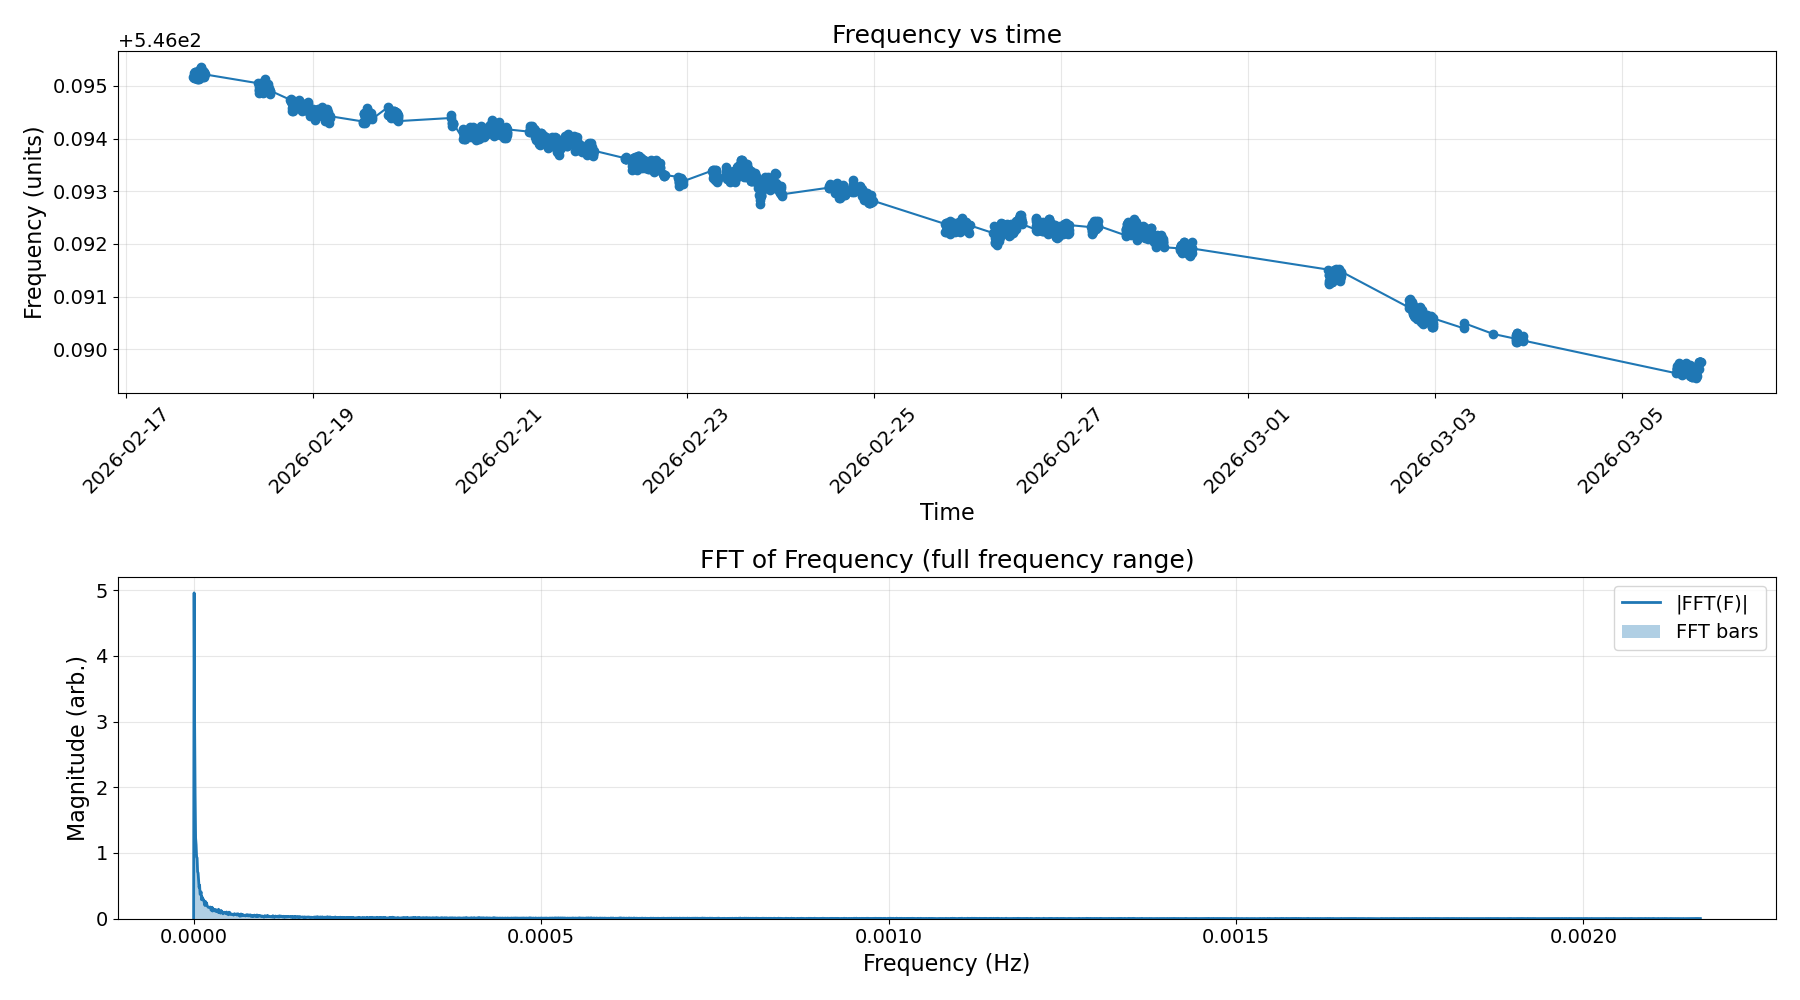

In [14]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# ---------- CONFIG ----------
folder_paths = [
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_Ramsey_calibrations",
    r"Z:\Lab Data\D52_Calibration_Ba137\RFSoC_Fast_bussed_Ramsey_daily_calibrations",
]

start_date = datetime(2026, 2, 17, 0, 0, 0)  # Change to desired start datetime
end_date = datetime(2026, 12, 15, 0, 0, 59)  # Change to desired end datetime (Optional)

# which frequency index to FFT: 0 = first frequency, 1 = second frequency
FREQ_INDEX = 0

# FFT settings
TAKE_DERIVATIVE = False   # True => FFT of d(f)/dt instead of f

# Plot styling
FIGSIZE = (18, 10)
FONT_SIZE = 16
# ---------------------------


def collect_freq_times(folder_paths, start_date, end_date, freq_index=0):
    times = []
    freqs = []

    for folder_path in folder_paths:
        if not os.path.isdir(folder_path):
            print(f"Skipping missing folder: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            file_path = os.path.join(folder_path, filename)
            if not os.path.isfile(file_path):
                continue

            mod_time = datetime.fromtimestamp(os.path.getmtime(file_path))
            if not (start_date <= mod_time <= end_date):
                continue

            try:
                with open(file_path, "r") as f:
                    lines = f.readlines()
                    top_list = json.loads(lines[0].strip())  # frequency list on line 0

                if isinstance(top_list, list) and len(top_list) > freq_index:
                    times.append(mod_time)
                    freqs.append(float(top_list[freq_index]))
            except Exception as e:
                print(f"Skipping {file_path}: {e}")

    if not times:
        return np.array([]), np.array([])

    idx = np.argsort(np.array(times, dtype=object))
    times = np.array(times, dtype=object)[idx]
    freqs = np.array(freqs, dtype=float)[idx]
    return times, freqs


def uniform_resample_for_fft(times_dt, y):
    """
    Convert datetimes to seconds from start and interpolate onto a uniform grid.
    Returns t_uniform_seconds, y_uniform, dt
    """
    t0 = times_dt[0]
    t_s = np.array([(t - t0).total_seconds() for t in times_dt], dtype=float)

    diffs = np.diff(t_s)
    diffs = diffs[diffs > 0]
    if diffs.size == 0:
        raise ValueError("Not enough distinct time points to estimate dt.")
    dt = np.median(diffs)

    t_uniform = np.arange(t_s[0], t_s[-1] + dt / 2, dt)
    y_uniform = np.interp(t_uniform, t_s, y)
    return t_uniform, y_uniform, dt


def plot_freq_and_fft(times_dt, freqs, take_derivative=False):
    plt.rcParams.update({
        "font.size": FONT_SIZE,
        "axes.titlesize": FONT_SIZE + 2,
        "axes.labelsize": FONT_SIZE,
        "xtick.labelsize": FONT_SIZE - 2,
        "ytick.labelsize": FONT_SIZE - 2,
        "legend.fontsize": FONT_SIZE - 2,
    })

    if freqs.size < 2:
        raise ValueError("Need at least 2 frequency points to compute FFT.")

    # Uniform resample for FFT
    t_uniform_s, y_uniform, dt = uniform_resample_for_fft(times_dt, freqs)

    # Optionally differentiate before FFT
    if take_derivative:
        y_proc = np.gradient(y_uniform, dt)  # units: (your freq units)/s
        top_y = y_proc
        top_title = "d(Frequency)/dt vs time"
        top_ylabel = "dF/dt (units/s)"
        fft_title = "FFT of dF/dt (full frequency range)"
        fft_line_label = "|FFT(dF/dt)|"
    else:
        y_proc = y_uniform
        top_y = freqs
        top_title = "Frequency vs time"
        top_ylabel = "Frequency (units)"
        fft_title = "FFT of Frequency (full frequency range)"
        fft_line_label = "|FFT(F)|"

    # Remove mean (DC)
    y_fft = y_proc - np.mean(y_proc)

    # FFT
    freqs_hz = np.fft.rfftfreq(len(y_fft), d=dt)
    Y = np.fft.rfft(y_fft)
    mag = np.abs(Y)

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE)

    # Top: raw frequency vs datetime
    ax1.plot(times_dt, top_y, marker="o", linestyle="-")
    ax1.set_xlabel("Time")
    ax1.set_ylabel(top_ylabel)
    ax1.set_title(top_title)
    ax1.grid(True, alpha=0.3)
    for tick in ax1.get_xticklabels():
        tick.set_rotation(45)

    # Bottom: FFT with bars + line (histogram-like)
    if len(freqs_hz) > 1:
        df = np.median(np.diff(freqs_hz))
        bar_width = 0.9 * df
    else:
        bar_width = 1.0

    ax2.bar(freqs_hz, mag, width=bar_width, alpha=0.35, align="center", label="FFT bars")
    ax2.plot(freqs_hz, mag, linewidth=2, label=fft_line_label)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("Magnitude (arb.)")
    ax2.set_title(fft_title)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


# if __name__ == "__main__":
times_dt, freqs = collect_freq_times(folder_paths, start_date, end_date, freq_index=FREQ_INDEX)
print("Points loaded:", len(freqs))

if len(freqs) == 0:
    raise SystemExit("No data found in the specified date range / folders.")

plot_freq_and_fft(times_dt, freqs, take_derivative=TAKE_DERIVATIVE)